In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pyunicorn.timeseries import RecurrencePlot, CrossRecurrencePlot, JointRecurrencePlot
import recurrence as rec

In [54]:
# Parameters
a = 0.25
b = 0.25
c = 40


# Coupled rossler
def coupled_rossler(t, state, eps):
    x1, y1, z1, x2, y2, z2 = state

    dxdt1 = -y1 - z1
    dydt1 = x1 + a * y1
    dzdt1 = b + z1 * (x1 - c)

    dxdt2 = -y2 - z2 + eps * (x1 - x2)
    dydt2 = x2 + a * y2
    dzdt2 = b + z2 * (x2 - c)

    return [dxdt1, dydt1, dzdt1, dxdt2, dydt2, dzdt2]

In [55]:
eps = 0.3   # coupling strength

t_span = (0, 500)
t_eval = np.linspace(0, 500, 2000)

init = [1,1,1, 2,2,2]

sol = solve_ivp(coupled_rossler, t_span, init, t_eval=t_eval, args=(eps,))

In [57]:
# Extract time series
#x1 = sol.y[0]
x1 = sol.y[:3].T
#x2 = sol.y[3]
x2 = sol.y[3:].T
t = sol.t

# Discard the first 100 time steps
x1 = x1[100:]
x2 = x2[100:]
t = t[100:]

# Normalize
#x1 = (x1 - np.mean(x1)) / np.std(x1)
#x2 = (x2 - np.mean(x2)) / np.std(x2)

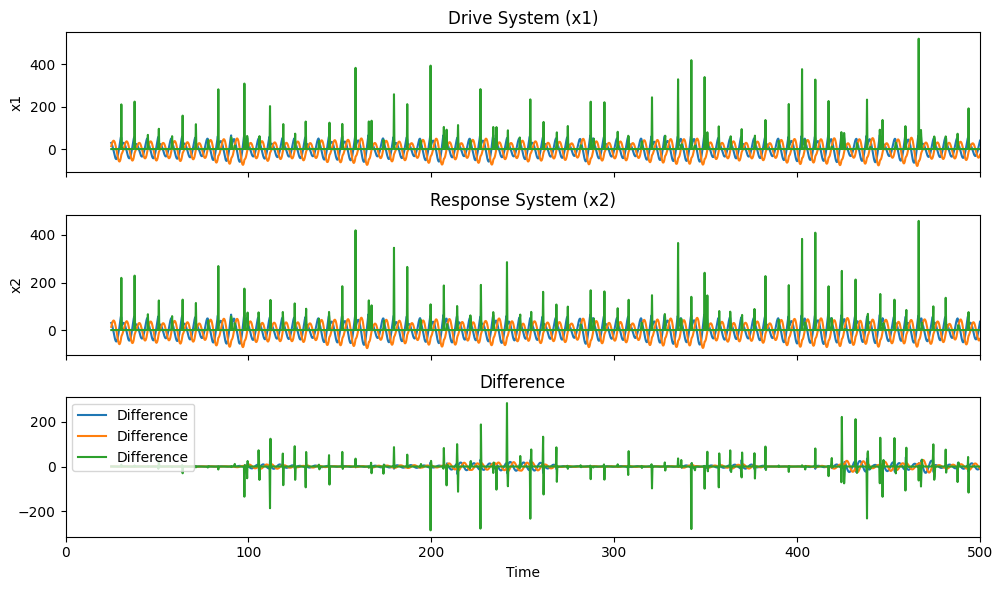

In [58]:
# Plot using subplots
fig, ax = plt.subplots(3, 1, figsize=(10,6), sharex=True)

ax[0].plot(t, x1)
ax[0].set_title("Drive System (x1)")
ax[0].set_ylabel("x1")

ax[1].plot(t, x2)
ax[1].set_title("Response System (x2)")

ax[1].set_ylabel("x2")

ax[2].plot(t, x2-x1, label='Difference')
ax[2].set_title("Difference")
ax[2].legend()
ax[2].set_xlabel("Time")

plt.tight_layout()
plt.xlim(0, t[-1])
plt.show()

In [59]:
# Recurrence plots without embedding
rr = 0.06

rp1 = RecurrencePlot(x1, recurrence_rate=rr)
RP1 = rp1.recurrence_matrix()

rp2 = RecurrencePlot(x2, recurrence_rate=rr)
RP2 = rp2.recurrence_matrix()

# Cross recurrence
crp = CrossRecurrencePlot(x1, x2, recurrence_rate=rr)
CRP = crp.recurrence_matrix()

# Joint recurrence
jrp = JointRecurrencePlot(x1, x2, recurrence_rate=(rr, rr))
JRP = jrp.recurrence_matrix()

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating the supremum distance matrix...


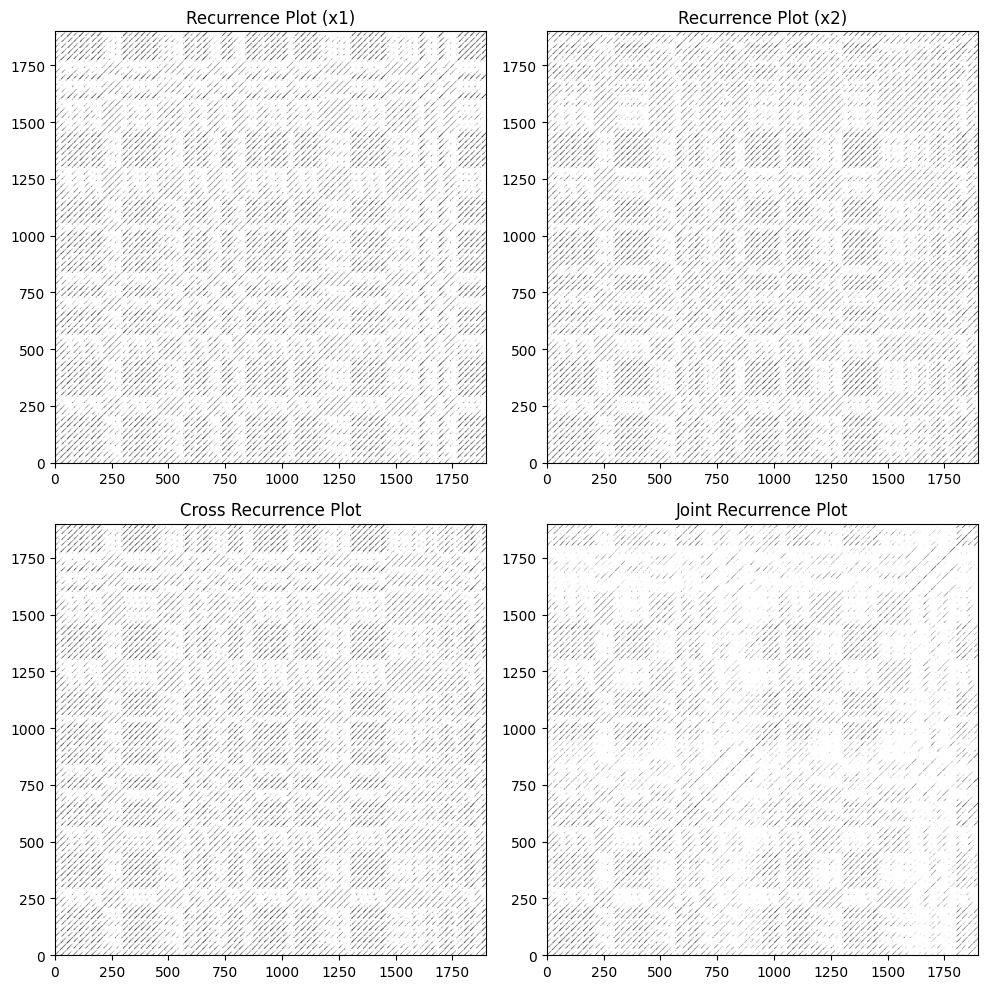

In [60]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

ax[0,0].imshow(RP1, cmap='binary', origin='lower')
ax[0,0].set_title("Recurrence Plot (x1)")

ax[0,1].imshow(RP2, cmap='binary', origin='lower')
ax[0,1].set_title("Recurrence Plot (x2)")

ax[1,0].imshow(CRP, cmap='binary', origin='lower')
ax[1,0].set_title("Cross Recurrence Plot")

ax[1,1].imshow(JRP, cmap='binary', origin='lower')
ax[1,1].set_title("Joint Recurrence Plot")

plt.tight_layout()
plt.show()

Lag from Tau Recurrence Rate: 1851


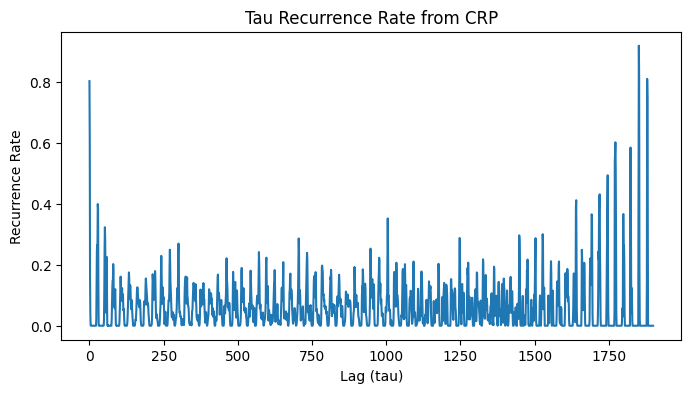

In [61]:
# Tau - Recurrence Rate

tau_rr = rec.tau_recurrence(CRP)

lag_tau = np.argmax(tau_rr)

print("Lag from Tau Recurrence Rate:", lag_tau)

plt.figure(figsize=(8,4))
plt.plot(tau_rr)
plt.xlabel("Lag (tau)")
plt.ylabel("Recurrence Rate")
plt.title("Tau Recurrence Rate from CRP")
plt.show()

CPR = 0.827583174322153


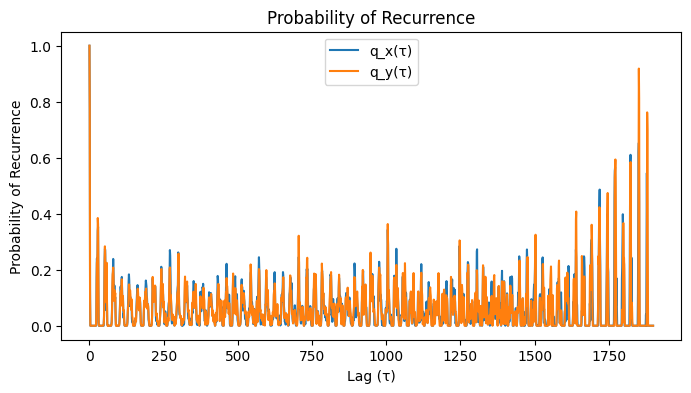

In [62]:
# CPR between 2 systems

CPR_value = rec.cpr(RP1, RP2)

print("CPR =", CPR_value)

qx = rec.tau_recurrence(RP1)
qy = rec.tau_recurrence(RP2)

plt.figure(figsize=(8,4))
plt.plot(qx, label="q_x(τ)")
plt.plot(qy, label="q_y(τ)")
plt.xlabel("Lag (τ)")
plt.ylabel("Probability of Recurrence")
plt.legend()
plt.title("Probability of Recurrence")
plt.show()

In [63]:
'''
from scipy.signal import correlate
import numpy as np
import matplotlib.pyplot as plt

corr = correlate(x2 - np.mean(x2), x1 - np.mean(x1), mode="full")
lags = np.arange(-len(x1)+1, len(x1))

plt.plot(lags, corr)
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("Cross Correlation")
plt.show()

lag = lags[np.argmax(corr)]
print("Estimated lag:", lag)
'''

'\nfrom scipy.signal import correlate\nimport numpy as np\nimport matplotlib.pyplot as plt\n\ncorr = correlate(x2 - np.mean(x2), x1 - np.mean(x1), mode="full")\nlags = np.arange(-len(x1)+1, len(x1))\n\nplt.plot(lags, corr)\nplt.xlabel("Lag")\nplt.ylabel("Correlation")\nplt.title("Cross Correlation")\nplt.show()\n\nlag = lags[np.argmax(corr)]\nprint("Estimated lag:", lag)\n'

## Test


Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


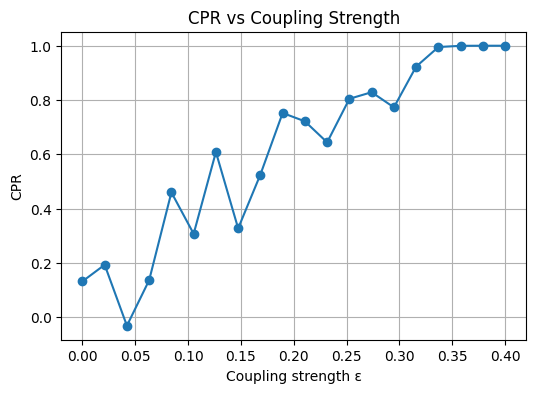

In [69]:
from scipy.integrate import solve_ivp
from pyunicorn.timeseries import RecurrencePlot
import numpy as np

eps_values = np.linspace(0, 0.4, 20)
cpr_values = []

for eps in eps_values:

    sol = solve_ivp(
        coupled_rossler,
        (0, 500),
        [1,1,1,2,2,2],
        t_eval=np.linspace(0,500,5000),
        args=(eps,)
    )       
    

    #x1 = sol.y[0]
    x1 = sol.y[:3].T
    #x2 = sol.y[3]
    x2 = sol.y[3:].T

    # remove transient
    transient = 1000
    x1 = x1[transient:]
    x2 = x2[transient:]

    # normalization
    #x1 = (x1 - np.mean(x1)) / np.std(x1)
    x1 = (x1 - np.mean(x1, axis = 0)) / np.std(x1, axis = 0)
    #x2 = (x2 - np.mean(x2)) / np.std(x2)
    x2 = (x2 - np.mean(x2, axis = 0)) / np.std(x2, axis = 0)

    # recurrence plots
    #rp1 = RecurrencePlot(x1, dim=3, tau=10, recurrence_rate=0.05)
    rp1 = RecurrencePlot(x1, recurrence_rate=0.05)
    RP1 = rp1.recurrence_matrix()

    #rp2 = RecurrencePlot(x2, dim=3, tau=10, recurrence_rate=0.05)
    rp2 = RecurrencePlot(x2, recurrence_rate=0.05)
    RP2 = rp2.recurrence_matrix()

    # compute CPR
    C = rec.cpr(RP1, RP2)

    cpr_values.append(C)


plt.figure(figsize=(6,4))

plt.plot(eps_values, cpr_values, marker='o')

plt.xlabel("Coupling strength ε")
plt.ylabel("CPR")
plt.title("CPR vs Coupling Strength")

plt.grid(True)

plt.show()

In [70]:
#Store low synch ts
low_sol = solve_ivp(
        coupled_rossler,
        (0, 500),
        [1,1,1,2,2,2],
        t_eval=np.linspace(0,500,5000),
        args=(0.06,)
    )       
    

low_x1 = low_sol.y[:3].T

low_x2 = low_sol.y[3:].T

# remove transient
transient = 1000
low_x1 = low_x1[transient:]
low_x2 = low_x2[transient:]

# normalization
low_x1 = (low_x1 - np.mean(low_x1, axis = 0)) / np.std(low_x1, axis = 0)
low_x2 = (low_x2 - np.mean(low_x2, axis = 0)) / np.std(low_x2, axis = 0)

# recurrence plots
rp1 = RecurrencePlot(low_x1, recurrence_rate=0.05)
RP1 = rp1.recurrence_matrix()

rp2 = RecurrencePlot(low_x2, recurrence_rate=0.05)
RP2 = rp2.recurrence_matrix()

# compute CPR
C = rec.cpr(RP1, RP2)

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


In [73]:
import pandas as pd

# convert arrays into dataframe
DF1 = pd.DataFrame(low_x1)
DF2 = pd.DataFrame(low_x2)

# save the dataframe as a csv file
DF1.to_csv("LS_nosynch1.csv", index=False)
DF2.to_csv("LS_nosynch2.csv", index=False)

In [74]:
#Store high synch ts
hi_sol = solve_ivp(
        coupled_rossler,
        (0, 500),
        [1,1,1,2,2,2],
        t_eval=np.linspace(0,500,5000),
        args=(0.32,)
    )       
    

hi_x1 = hi_sol.y[:3].T

hi_x2 = hi_sol.y[3:].T

# remove transient
transient = 1000
hi_x1 = hi_x1[transient:]
hi_x2 = hi_x2[transient:]

# normalization
hi_x1 = (hi_x1 - np.mean(hi_x1, axis = 0)) / np.std(hi_x1, axis = 0)
hi_x2 = (hi_x2 - np.mean(hi_x2, axis = 0)) / np.std(hi_x2, axis = 0)

# recurrence plots
rp1 = RecurrencePlot(hi_x1, recurrence_rate=0.05)
RP1 = rp1.recurrence_matrix()

rp2 = RecurrencePlot(hi_x2, recurrence_rate=0.05)
RP2 = rp2.recurrence_matrix()

# compute CPR
C = rec.cpr(RP1, RP2)

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


In [75]:
C

0.8879398638647029

In [76]:
import pandas as pd

# convert arrays into dataframe
DF1 = pd.DataFrame(hi_x1)
DF2 = pd.DataFrame(hi_x2)

# save the dataframe as a csv file
DF1.to_csv("LS_synch1.csv", index=False)
DF2.to_csv("LS_synch2.csv", index=False)